In [16]:
from selenium import webdriver
from selenium.webdriver.chrome.service import Service
from selenium.webdriver.chrome.options import Options
from webdriver_manager.chrome import ChromeDriverManager
from selenium.webdriver.support import expected_conditions as EC
from selenium.webdriver.common.by import By
from selenium.common.exceptions import NoSuchElementException
import pandas as pd
import re
import matplotlib.pyplot as plt
import numpy as np

In [46]:
chrome_options = Options()
#chrome_options.add_argument("--headless") # Décommenter pour cacher la fenêtre
#Lancement du navigateur (Chrome) + installation même version que le naviateur si besoin
driver = webdriver.Chrome(service=Service(ChromeDriverManager().install()), options=chrome_options)

BASE_URL = "https://www.cdiscount.com/search/10/climatiseur+mobile.html?page="
list_products = []
page = 1

try:
    while True:
        url = f"{BASE_URL}{page}"
        driver.get(url)
        # ! Attendre que le JS est chargé le code HTML
        print("Attente du chargement des scripts")
        #http://selenium.dev/documentation/webdriver/waits/
        driver.implicitly_wait(10)


        # Extraire les données
        # Ici, on utilise les sélecteurs de Selenium, on récupère la div qui représente le produit
        products = driver.find_elements(By.CLASS_NAME, "sc-11c3ifi-8")
        print(f"\n{len(products)} produits trouvés à la page {page} :\n")
        for product in products:
            list_products.append(product.text)

        # Boucle pour afficher les résultats
        """for i in range(len(products)):
            print(f"{products[i].text}")
            print("-" * 20)"""

        # Rechercher le lien "Suivant" à partir de la page actuelle
        links = driver.find_elements(By.CLASS_NAME, "sc-fsvrbR")
        next_link = ""
        for link in links:
            if "Suivant" in link.text:
                next_link = link
                break

        page+=1
        if next_link=="":
            break
finally:
    # !!! fermer le navigateur à la fin
    driver.quit()

Attente du chargement des scripts

61 produits trouvés à la page 1 :

Attente du chargement des scripts

62 produits trouvés à la page 2 :

Attente du chargement des scripts

62 produits trouvés à la page 3 :

Attente du chargement des scripts

62 produits trouvés à la page 4 :

Attente du chargement des scripts

62 produits trouvés à la page 5 :

Attente du chargement des scripts

62 produits trouvés à la page 6 :

Attente du chargement des scripts

62 produits trouvés à la page 7 :

Attente du chargement des scripts

62 produits trouvés à la page 8 :

Attente du chargement des scripts

58 produits trouvés à la page 9 :

Attente du chargement des scripts

47 produits trouvés à la page 10 :

Attente du chargement des scripts

47 produits trouvés à la page 11 :

Attente du chargement des scripts

47 produits trouvés à la page 12 :

Attente du chargement des scripts

47 produits trouvés à la page 13 :

Attente du chargement des scripts

47 produits trouvés à la page 14 :

Attente du char

In [ ]:
print(list_products)
df  = pd.DataFrame(list_products, columns=["Produit"])
df.to_excel("produits.xlsx", index=False)

["Sponsorisé?\nClimatiseurs Portables, Refroidisseur par évaporation, minuterie , 3 Vitesses, Deux réservoirs d'eau de 15 L, télécommande,Blanc\nLivraison gratuite1\n145,99 €\nAjouter", 'Sponsorisé?\nKit fenêtre pour climatiseur ELECTROLUX EWKIT5\nLivraison gratuite1\n79,99 €\nAjouter', "Climatiseur Portable avec 3 Vitesses, minuterie 7.5 h, réservoir de 6 L, rafraîchisseur d'air par évaporation avec télécommande,Noir\nLivraison gratuite1\n145,99 €\nAjouter", "Climatiseur Mobile Sans Évacuation,10 L, 65 W,Avec minuterie 7 h, 65 dB Oscillation à 120°,Réservoir d'eau amovible Télécommande\nLivraison gratuite1\n235,99 €\nAjouter", 'Climatiseur Mobile Rafraîchisseur d’Air, Réservoir 6L, 4 Blocs Réfrigérants, 60W Économie d’Énergie, 40dB Silencieux,3 Vitesses\nLivraison gratuite1\n183,99 €\nAjouter', "Climatiseur Mobile Portable Refroidisseur d'air avec Réservoir 5L 3 Vitesse Refroidisseur par évaporation avec Télécommande,Blanc\nLivraison gratuite1\n155,99 €\nAjouter", 'Mini Climatiseur Po

In [ ]:
products = pd.read_excel("produits.xlsx")

                                                Produit
0     Sponsorisé?\nClimatiseurs Portables, Refroidis...
1     Sponsorisé?\nKit fenêtre pour climatiseur ELEC...
2     Climatiseur Portable avec 3 Vitesses, minuteri...
3     Climatiseur Mobile Sans Évacuation,10 L, 65 W,...
4     Climatiseur Mobile Rafraîchisseur d’Air, Réser...
...                                                 ...
2900  Promo\nAPPLE iPhone 15 128GB Black (2023)\n3,8...
2901  Machine à boissons glacées et granitées NINJA ...
2902  Promo\nTefal Ingenio Emotion Batterie de cuisi...
2903  Friteuse sans huile NINJA - Foodi AF200EU - Ca...
2904  Bon plan\nAPPLE AirPods 4\n4,6 / 5\nPrix de co...

[2905 rows x 1 columns]


In [ ]:
def convertir_prix(prix):
    return float(prix.replace("€", "").replace(" ", "").replace(",", "."))

rows = []

for produit in products["Produit"]:
    lignes = str(produit).split("\n")
    nouvelles_lignes = []

    for ligne in lignes:
        ligne_nettoyee = ligne.strip()
        if ligne_nettoyee:
            nouvelles_lignes.append(ligne_nettoyee)

    lignes = nouvelles_lignes

    sponsorise = "Oui" if lignes and "Sponsorisé" in lignes[0] else "Non"
    promo = "Oui" if lignes and "Promo" in lignes[0] else "Non"
    bon_plan = "Oui" if lignes and "Bon plan" in lignes[0] else "Non"

    if sponsorise == "Oui" or promo == "Oui" or bon_plan == "Oui": # Dans lignes, si le produit est sponsorisé ou en promotion ou en bon plan, le nom du produit se trouve à la colonne 1, sinon à la colonne 0
        nom = lignes[1] if len(lignes) > 1 else ""
    else:
        nom = lignes[0] if len(lignes) > 0 else ""

    texte = "\n".join(lignes)
    prix_actuel = ""
    prix_avant_reduction = ""
    taux_reduction = ""

    if "Prix de comparaison" in texte: # Si y a un prix de comparaison, on va chercher le prix avant réduction et le prix actuel
        partie_reduction = texte.split("Prix de comparaison", 1)[1]
        prix_trouves = re.findall(r"\d+(?:,\d{2})?\s*€", partie_reduction)

        prix_avant_reduction = convertir_prix(prix_trouves[0])
        prix_actuel = convertir_prix(prix_trouves[1])
        if prix_avant_reduction > 0:
            taux_reduction = round(
                ((prix_avant_reduction - prix_actuel) / prix_avant_reduction) * 100, 2
            )
    else:
        prix_trouves = re.findall(r"\d+(?:,\d{2})?\s*€", texte)
        if len(prix_trouves) >= 1:
            prix_actuel = convertir_prix(prix_trouves[-1])

    rows.append(
        {
            "nom": nom,
            "sponsorise": sponsorise,
            "promo": promo,
            "bon plan": bon_plan,
            "prix_actuel": prix_actuel,
            "prix_avant_reduction": prix_avant_reduction,
            "taux_reduction_%": taux_reduction,
        }
    )

df_clean = pd.DataFrame(rows)

df_clean = df_clean[
    df_clean["nom"].str.contains("clim|ventilateur", case=False, na=False)
]

df_clean.to_excel("produits_clean.xlsx", index=False)

df_clean

,nom,sponsorise,promo,bon plan,prix_actuel,prix_avant_reduction,taux_reduction_%
0,"Climatiseurs Portables, Refroidisseur par évap...",Oui,Non,Non,145.99,,
1,Kit fenêtre pour climatiseur ELECTROLUX EWKIT5,Oui,Non,Non,79.99,,
2,"Climatiseur Portable avec 3 Vitesses, minuteri...",Non,Non,Non,145.99,,
3,"Climatiseur Mobile Sans Évacuation,10 L, 65 W,...",Non,Non,Non,235.99,,
4,"Climatiseur Mobile Rafraîchisseur d’Air, Réser...",Non,Non,Non,183.99,,
...,...,...,...,...,...,...,...
2900,APPLE iPhone 15 128GB Black (2023),Non,Oui,Non,379.96,,
2901,Machine à boissons glacées et granitées NINJA ...,Non,Non,Non,189.99,,
2902,Tefal Ingenio Emotion Batterie de cuisine 13 p...,Non,Oui,Non,89.99,,
2903,Friteuse sans huile NINJA - Foodi AF200EU - Ca...,Non,Non,Non,99.99,179.99,44.45


In [ ]:
# Analyse du taux de réduction en fonction du prix actuel
# Est-ce que les produits chers ont tendance à avoir des réductions plus fortes que les produits peu chers
df_clean["taux_reduction_%"] = df_clean["taux_reduction_%"].replace("", 0)

df_relation = df_clean.copy()

df_relation = df_relation[df_relation["taux_reduction_%"] > 0]  # Filtrer les produits avec un taux de réduction supérieur à 0


df_relation["prix_actuel"] = pd.to_numeric(
    df_relation["prix_actuel"], errors="coerce"
)

df_relation["taux_reduction_%"] = pd.to_numeric(
    df_relation["taux_reduction_%"], errors="coerce"
)

correlation = df_relation["prix_actuel"].corr(df_relation["taux_reduction_%"])

print(
    "Corrélation entre prix actuel et taux de réduction :", round(correlation, 3)
)

Corrélation entre prix actuel et taux de réduction : -0.096


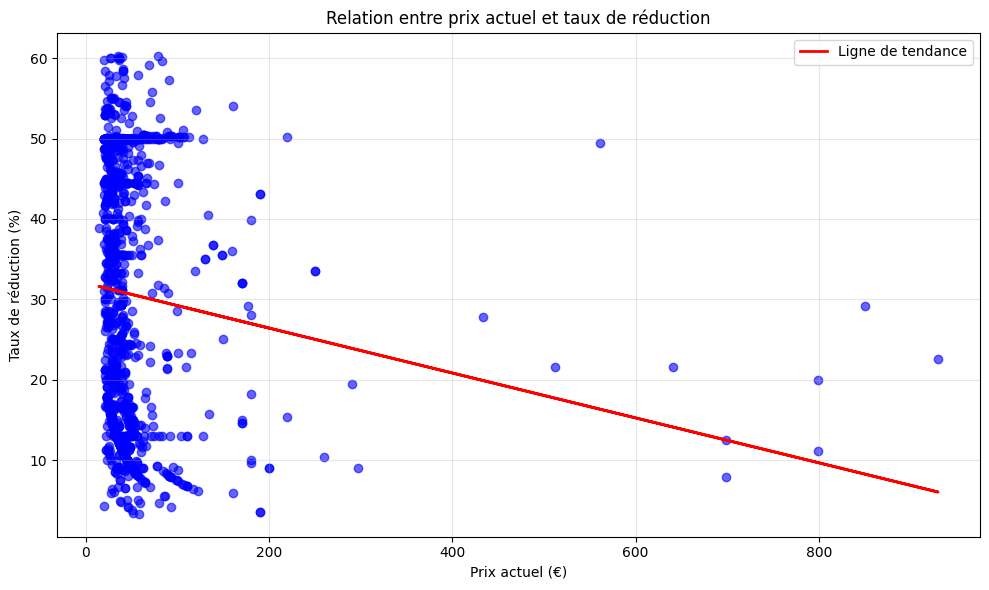

Conclusion : corrélation faible. Il n'y a pas de relation claire entre le prix et le taux de réduction.


In [24]:
x = df_relation["prix_actuel"]
y = df_relation["taux_reduction_%"]

a, b = np.polyfit(x, y, 1)

plt.figure(figsize=(10, 6))

plt.scatter(x, y, alpha=0.6, color="blue")

plt.plot(x, a * x + b, color="red", linewidth=2, label="Ligne de tendance")

plt.title("Relation entre prix actuel et taux de réduction")
plt.xlabel("Prix actuel (€)")
plt.ylabel("Taux de réduction (%)")

plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

if correlation > 0.5:
    print(
        "Conclusion : relation positive forte. Les produits chers semblent avoir des réductions plus élevées."
    )
elif correlation > 0.2:
    print(
        "Conclusion : relation positive faible à modérée. Les produits chers ont légèrement tendance à avoir des réductions plus élevées."
    )
elif correlation > -0.2:
    print(
        "Conclusion : corrélation faible. Il n'y a pas de relation claire entre le prix et le taux de réduction."
    )
else:
    print(
        "Conclusion : relation négative. Les produits moins chers semblent avoir des réductions plus élevées."
    )